In [1]:

# Cargar los datos de los individuos
import sys

# Ajusto  para que la reconozca la ruta del proyecto
sys.path.append("..")

import pandas as pd
import streamlit as st
from src.utils.constants import INDIVIDUOS_PROCESSED_DIR, HOGARES_PROCESSED_DIR
import matplotlib.pyplot as plt
%matplotlib inline


## CARGO DATASET

In [2]:
# Cargar datos procesados (asegúrate de tener bien la ruta)
df_individuos =pd.read_csv(INDIVIDUOS_PROCESSED_DIR, sep=";", encoding="utf-8")

C:\Users\PC\AppData\Local\Temp\ipykernel_10656\3836285256.py:2: DtypeWarning: Columns (99,106,114) have mixed types. Specify dtype option on import or set low_memory=False.
  df_individuos =pd.read_csv(INDIVIDUOS_PROCESSED_DIR, sep=";", encoding="utf-8")


##  Creo mis dataset filtrado 

In [3]:
df_individuos   #Aca despues que termines achicalo acordate

,PP07G1,PP02H,PDECIFR,P21,DECINDR,PP08J2,PP10D,CH08,DECOCUR,PP06E,...,PP04B2,PP06D,V3_M,ADECCFR,PP11B2_ANO,PP03I,CH04_str,NIVEL_ED_str,CONDICION_LABORAL,UNIVERSITARIO
0,NaN,0,10.0,0,0,NaN,NaN,1.0,0,NaN,...,NaN,NaN,0,5,NaN,NaN,Masculino,Primario incompleto,Fuera de categoría/sin información,2
1,NaN,2,6.0,0,8,NaN,NaN,1.0,0,NaN,...,NaN,NaN,0,9,NaN,NaN,Femenino,Secundario completo,Inactivo,0
2,1.0,0,8.0,130000,7,0.0,NaN,1.0,7,0.0,...,0.0,0.0,0,8,NaN,2.0,Femenino,Secundario completo,Ocupado dependiente,0
3,2.0,0,8.0,160000,8,0.0,NaN,1.0,8,0.0,...,0.0,0.0,0,8,NaN,2.0,Masculino,Secundario completo,Ocupado dependiente,0
4,2.0,0,12.0,50000,12,0.0,NaN,1.0,3,0.0,...,0.0,0.0,0,12,NaN,2.0,Masculino,Secundario incompleto,Ocupado dependiente,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146332,NaN,2,NaN,0,12,NaN,NaN,1.0,0,NaN,...,NaN,NaN,0,12,NaN,NaN,Masculino,Secundario incompleto,Inactivo,0
146333,0.0,0,5.0,50000,6,0.0,NaN,4.0,5,0.0,...,0.0,0.0,0,8,NaN,1.0,Masculino,Secundario completo,Ocupado autónomo,0
146334,1.0,0,5.0,30000,3,0.0,NaN,2.0,3,0.0,...,0.0,0.0,0,8,NaN,2.0,Femenino,Superior o universitario,Ocupado dependiente,0
146335,NaN,2,NaN,0,7,NaN,NaN,1.0,0,NaN,...,NaN,NaN,0,7,NaN,NaN,Masculino,Primario incompleto,Inactivo,0


In [4]:
# Armo mis variables para filtrar el dateset
anio_trim = df_individuos.groupby('ANO4')['TRIMESTRE'].unique().apply(list).to_dict()
anio_trim

{2021: [2], 2022: [2], 2023: [1]}

### 1.5.1 
Para las personas desocupadas, informar la cantidad de ellas según sus estudios alcanzados. Se debe informar para un año y trimestre elegido por el usuario.

Armado del df con los solicitado

In [5]:
st.title("Análisis de Desocupados por Nivel Educativo")

# Configuro el selector de año y trimestre
anio = st.selectbox("Seleccioná un año",anio_trim.keys())
trimestre = st.selectbox("Seleccioná un año", anio_trim[anio])

# Filtro por año, trimestre y condición laboral

df_filtrado = df_individuos[(df_individuos['ANO4'] == anio) & (df_individuos['TRIMESTRE'] == trimestre) & (df_individuos['CONDICION_LABORAL'] == 'Desocupado')]

# Agrupar por nivel educativo
df_educacion_desocupado = df_filtrado.groupby('NIVEL_ED_str')['PONDERA'].sum().sort_values(ascending=False)
df_educacion_desocupado

2025-05-30 03:05:18.981 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:05:25.159 
  command:

    streamlit run C:\Users\PC\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-05-30 03:05:25.166 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:05:25.172 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:05:25.175 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:05:25.177 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:05:25.181 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:05:25.184 Session

NIVEL_ED_str
Superior o universitario    447249
Secundario completo         391379
Secundario incompleto       290178
Primario completo           106527
Primario incompleto          32507
Sin Información               4662
Name: PONDERA, dtype: int64

Armo gráfico

Gráfico de barras


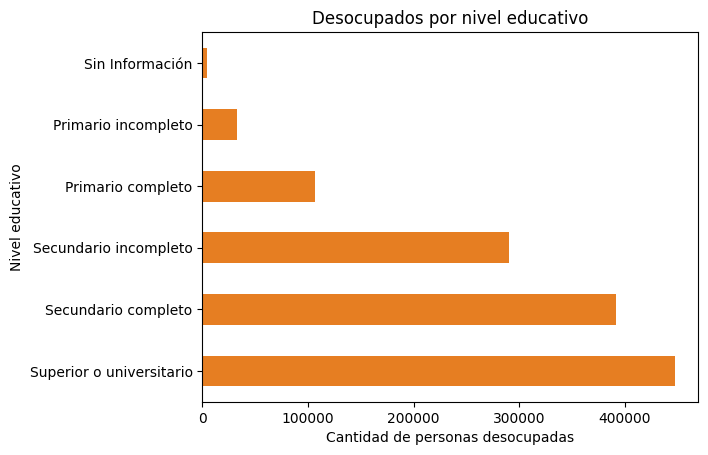

In [9]:

# Subtítulo (opcional en Jupyter, si querés podés imprimirlo)
print("Gráfico de barras")

# Crear la figura y el eje
fig, ax = plt.subplots()

# Dibujar el gráfico de barras horizontal
df_educacion_desocupado.plot(kind='barh', ax=ax, color="#E67E22")

# Etiquetas
ax.set_xlabel("Cantidad de personas desocupadas")
ax.set_ylabel("Nivel educativo")
ax.set_title("Desocupados por nivel educativo")

# Mostrar el gráfico
plt.show()

In [7]:
# Streamlit para mostrar el gráfico
st.subheader("Tabla de cantidad de desocupados por nivel educativo")
st.dataframe(df_educacion_desocupado.rename("Cantidad de Personas").to_frame())

2025-05-30 03:05:26.552 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:05:26.556 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:05:26.788 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:05:26.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [18]:
def calcular_tasa_desempleo(df, aglomerado=None):
    """
    Calcula la evolución de la tasa de desempleo por trimestre y año.
    Si se especifica un aglomerado, filtra por él.

    Parámetros:
    - df: DataFrame con columnas ANO4, TRIMESTRE, AGLOMERADO, CONDICION_LABORAL, PONDERA
    - aglomerado: (opcional) nombre del aglomerado a filtrar

    Devuelve:
    - DataFrame con columnas ANO4, TRIMESTRE y Tasa_Desempleo
    """
    if aglomerado:
        df = df[df['AGLOMERADO'] == aglomerado]

    grupo = df.groupby(['ANO4', 'TRIMESTRE'])

    df_tasa = grupo.apply(lambda g: 
        g[g['CONDICION_LABORAL'] == 'Desocupado']['PONDERA'].sum() /
        g[g['CONDICION_LABORAL'].isin(['Ocupado', 'Desocupado'])]['PONDERA'].sum() * 100
    ).reset_index(name='Tasa_Desempleo')

    return df_tasa.sort_values(by=['ANO4', 'TRIMESTRE'])


In [19]:
tasa_lp = calcular_tasa_desempleo(df_individuos, aglomerado='La Plata')


C:\Users\PC\AppData\Local\Temp\ipykernel_10656\2872049679.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tasa = grupo.apply(lambda g:


TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'

### 1.5.2 
Informar la evolución del desempleo(tasa de desempleo) a lo largo del tiempo. Se
debe poder filtrar por aglomerado y en caso de no elegir ninguno se debe calcular para todo
el país.
La tasa de desempleo es el cociente de personas desocupadas y la suma de personas
desocupadas más ocupadas multiplicado por 100.

BOTONES DE sELECCION DE AGLOMERADO

In [11]:
# --- Selector de aglomerado ---
from src.utils.constants import AGLOMERADOS_NOMBRES 


# TITULO 
st.title("Evolución de la tasa de desempleo")

#Boton de Filtro de aglomeradosimport streamlit as st
import pandas as pd
from src.utils.constants import AGLOMERADOS_NOMBRES

import streamlit as st
import pandas as pd
from src.utils.constants import AGLOMERADOS_NOMBRES

# Título
st.title("Evolución de la tasa de desempleo")

# Obtener los códigos únicos de aglomerados presentes en el DataFrame
aglomerados_disponibles = df_individuos['AGLOMERADO'].unique()

# Filtrar solo los nombres disponibles según los códigos que están en el dataframe
aglomerados_nombres_disponibles = {num_aglo: AGLOMERADOS_NOMBRES[num_aglo] for num_aglo in aglomerados_disponibles if num_aglo in AGLOMERADOS_NOMBRES}

# Mostrar el multiselect con los nombres de los aglomerados
seleccionados = st.multiselect("Seleccioná uno o más aglomerados (opcional)",options=aglomerados_nombres_disponibles.values(),default=aglomerados_nombres_disponibles.values())

# Invertir el diccionario para pasar de nombre a código
nombre_a_codigo = {v: k for k, v in aglomerados_nombres_disponibles.items()}

# Filtrar el DataFrame si se seleccionaron aglomerados
if seleccionados:
    codigos_filtrados = [nombre_a_codigo[nombre] for nombre in seleccionados]
    df_filtrado = df_individuos[df_individuos['AGLOMERADO'].isin(codigos_filtrados)]
else:
    df_filtrado = df_individuos.copy()


2025-05-30 03:14:48.928 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:14:48.930 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:14:48.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:14:48.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:14:48.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:14:48.948 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:14:48.950 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-30 03:14:48.951 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [12]:
anio_trim

{2021: [2], 2022: [2], 2023: [1]}

In [17]:
# Agrupar por año y trimestre
grupo = df_individuos.groupby(['ANO4', 'TRIMESTRE'])

# Calcular tasas de desempleo por grupo
df_tasa = grupo.apply(lambda g: 
    g[g['CONDICION_LABORAL'] == 'Desocupado']['PONDERA'].sum() /
    (g[g['CONDICION_LABORAL'].isin(['Ocupado', 'Desocupado'])]['PONDERA'].sum()) * 100
).reset_index(name='Tasa_Desempleo')

print(df_tasa)


   ANO4  TRIMESTRE  Tasa_Desempleo
0  2021          2           100.0
1  2022          2           100.0
2  2023          1           100.0


C:\Users\PC\AppData\Local\Temp\ipykernel_10656\1741399820.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tasa = grupo.apply(lambda g:


In [16]:
#La tasa de desempleo es el cociente de personas desocupadas y la suma de personas
#desocupadas más ocupadas multiplicado por 100.

Desocupado=df_individuos[df_individuos['CONDICION_LABORAL'] == 'Desocupado']['PONDERA'].sum()
Total=Desocupado + df_individuos[df_individuos['CONDICION_LABORAL'] == 'Ocupado']['PONDERA'].sum()


TypeError: 'DataFrameGroupBy' object does not support item assignment